In [22]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import xgboost as xgb
import numpy as np

In [2]:
data = pd.read_csv(r"C:\Users\amitp\Downloads\My datasets\Heart_Disease_Prediction.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [4]:
lst = data.columns
lst

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

In [5]:
for feature in lst:
    value = data[feature].value_counts()
    print(value)
    print("   ")

Age
54    16
58    15
60    12
59    12
57    12
51    12
62    11
52    11
44    10
64     9
56     9
41     9
65     8
67     8
42     8
50     7
43     7
46     7
63     7
48     7
45     7
53     7
61     7
66     6
55     6
49     5
70     4
47     4
69     3
68     3
40     3
71     3
39     3
35     3
37     2
34     2
74     1
76     1
38     1
77     1
29     1
Name: count, dtype: int64
   
Sex
1    183
0     87
Name: count, dtype: int64
   
Chest pain type
4    129
3     79
2     42
1     20
Name: count, dtype: int64
   
BP
120    34
130    31
140    30
110    17
150    17
160    11
125    10
112     9
138     9
128     9
118     7
135     6
108     6
132     6
124     5
145     5
100     4
134     4
152     4
142     3
115     3
136     3
105     3
126     3
180     3
122     3
170     2
178     2
94      2
102     2
101     1
104     1
106     1
156     1
174     1
144     1
146     1
165     1
148     1
158     1
200     1
192     1
117     1
123     1
129     1
155     1


In [6]:
numerical_features  = ['BP', 'Max HR', "Age", "ST depression", "Cholesterol"]
categorical_features = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST','Number of vessels fluro','Thallium']
X = data.drop(["Heart Disease"], axis = 1)
Y = data["Heart Disease"]
Y = data["Heart Disease"].apply(lambda x:1 if x == "Presence" else 0)

In [7]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y, random_state = 32,test_size = 0.20)

In [8]:
preprocessor = ColumnTransformer(
    transformers = [('std', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(sparse_output = False), categorical_features)
                   ])
# X_test = preprocessor.fit_transform(X_test)

In [23]:
models = {'Logistic Regression' : LogisticRegression(),
          'KNN Classifier' : KNeighborsClassifier(metric = 'euclidean', n_neighbors=12),
          'Random  Forest Classifier' : RandomForestClassifier(n_estimators = 300, random_state = 36, max_depth = 30),
          'XGB classifier' : xgb.XGBClassifier(n_estimators = 120, learning_rate = 0.01,max_depth = 20)
         }

In [24]:
pipelines = {name: Pipeline([('preproc', preprocessor),('model', model)]) for name, model in models.items()}

In [25]:
scores = {}

In [26]:
for name, pipe in pipelines.items():
    pipe.fit(X_train,Y_train)
    
    y_pred = pipe.predict(X_test)
    score = accuracy_score(Y_test, y_pred)
    report = classification_report(Y_test, y_pred)
    scores[name] = score
    print(f"{name}, accuracy_score : {score:.3f}")
    print(report)

Logistic Regression, accuracy_score : 0.815
              precision    recall  f1-score   support

           0       0.79      0.85      0.82        27
           1       0.84      0.78      0.81        27

    accuracy                           0.81        54
   macro avg       0.82      0.81      0.81        54
weighted avg       0.82      0.81      0.81        54

KNN Classifier, accuracy_score : 0.796
              precision    recall  f1-score   support

           0       0.77      0.85      0.81        27
           1       0.83      0.74      0.78        27

    accuracy                           0.80        54
   macro avg       0.80      0.80      0.80        54
weighted avg       0.80      0.80      0.80        54

Random  Forest Classifier, accuracy_score : 0.741
              precision    recall  f1-score   support

           0       0.74      0.74      0.74        27
           1       0.74      0.74      0.74        27

    accuracy                           0.74      

In [13]:
scores

{'Logistic Regression': 0.8148148148148148,
 'KNN Classifier': 0.7962962962962963,
 'Random  Forest Classifier': 0.7962962962962963}

In [27]:
data = pd.DataFrame(list(scores.items()), columns = ["Models","Score"])

In [28]:
data

,Models,Score
0,Logistic Regression,0.814815
1,KNN Classifier,0.796296
2,Random Forest Classifier,0.740741
3,XGB classifier,0.777778


<Axes: xlabel='Models', ylabel='Score'>

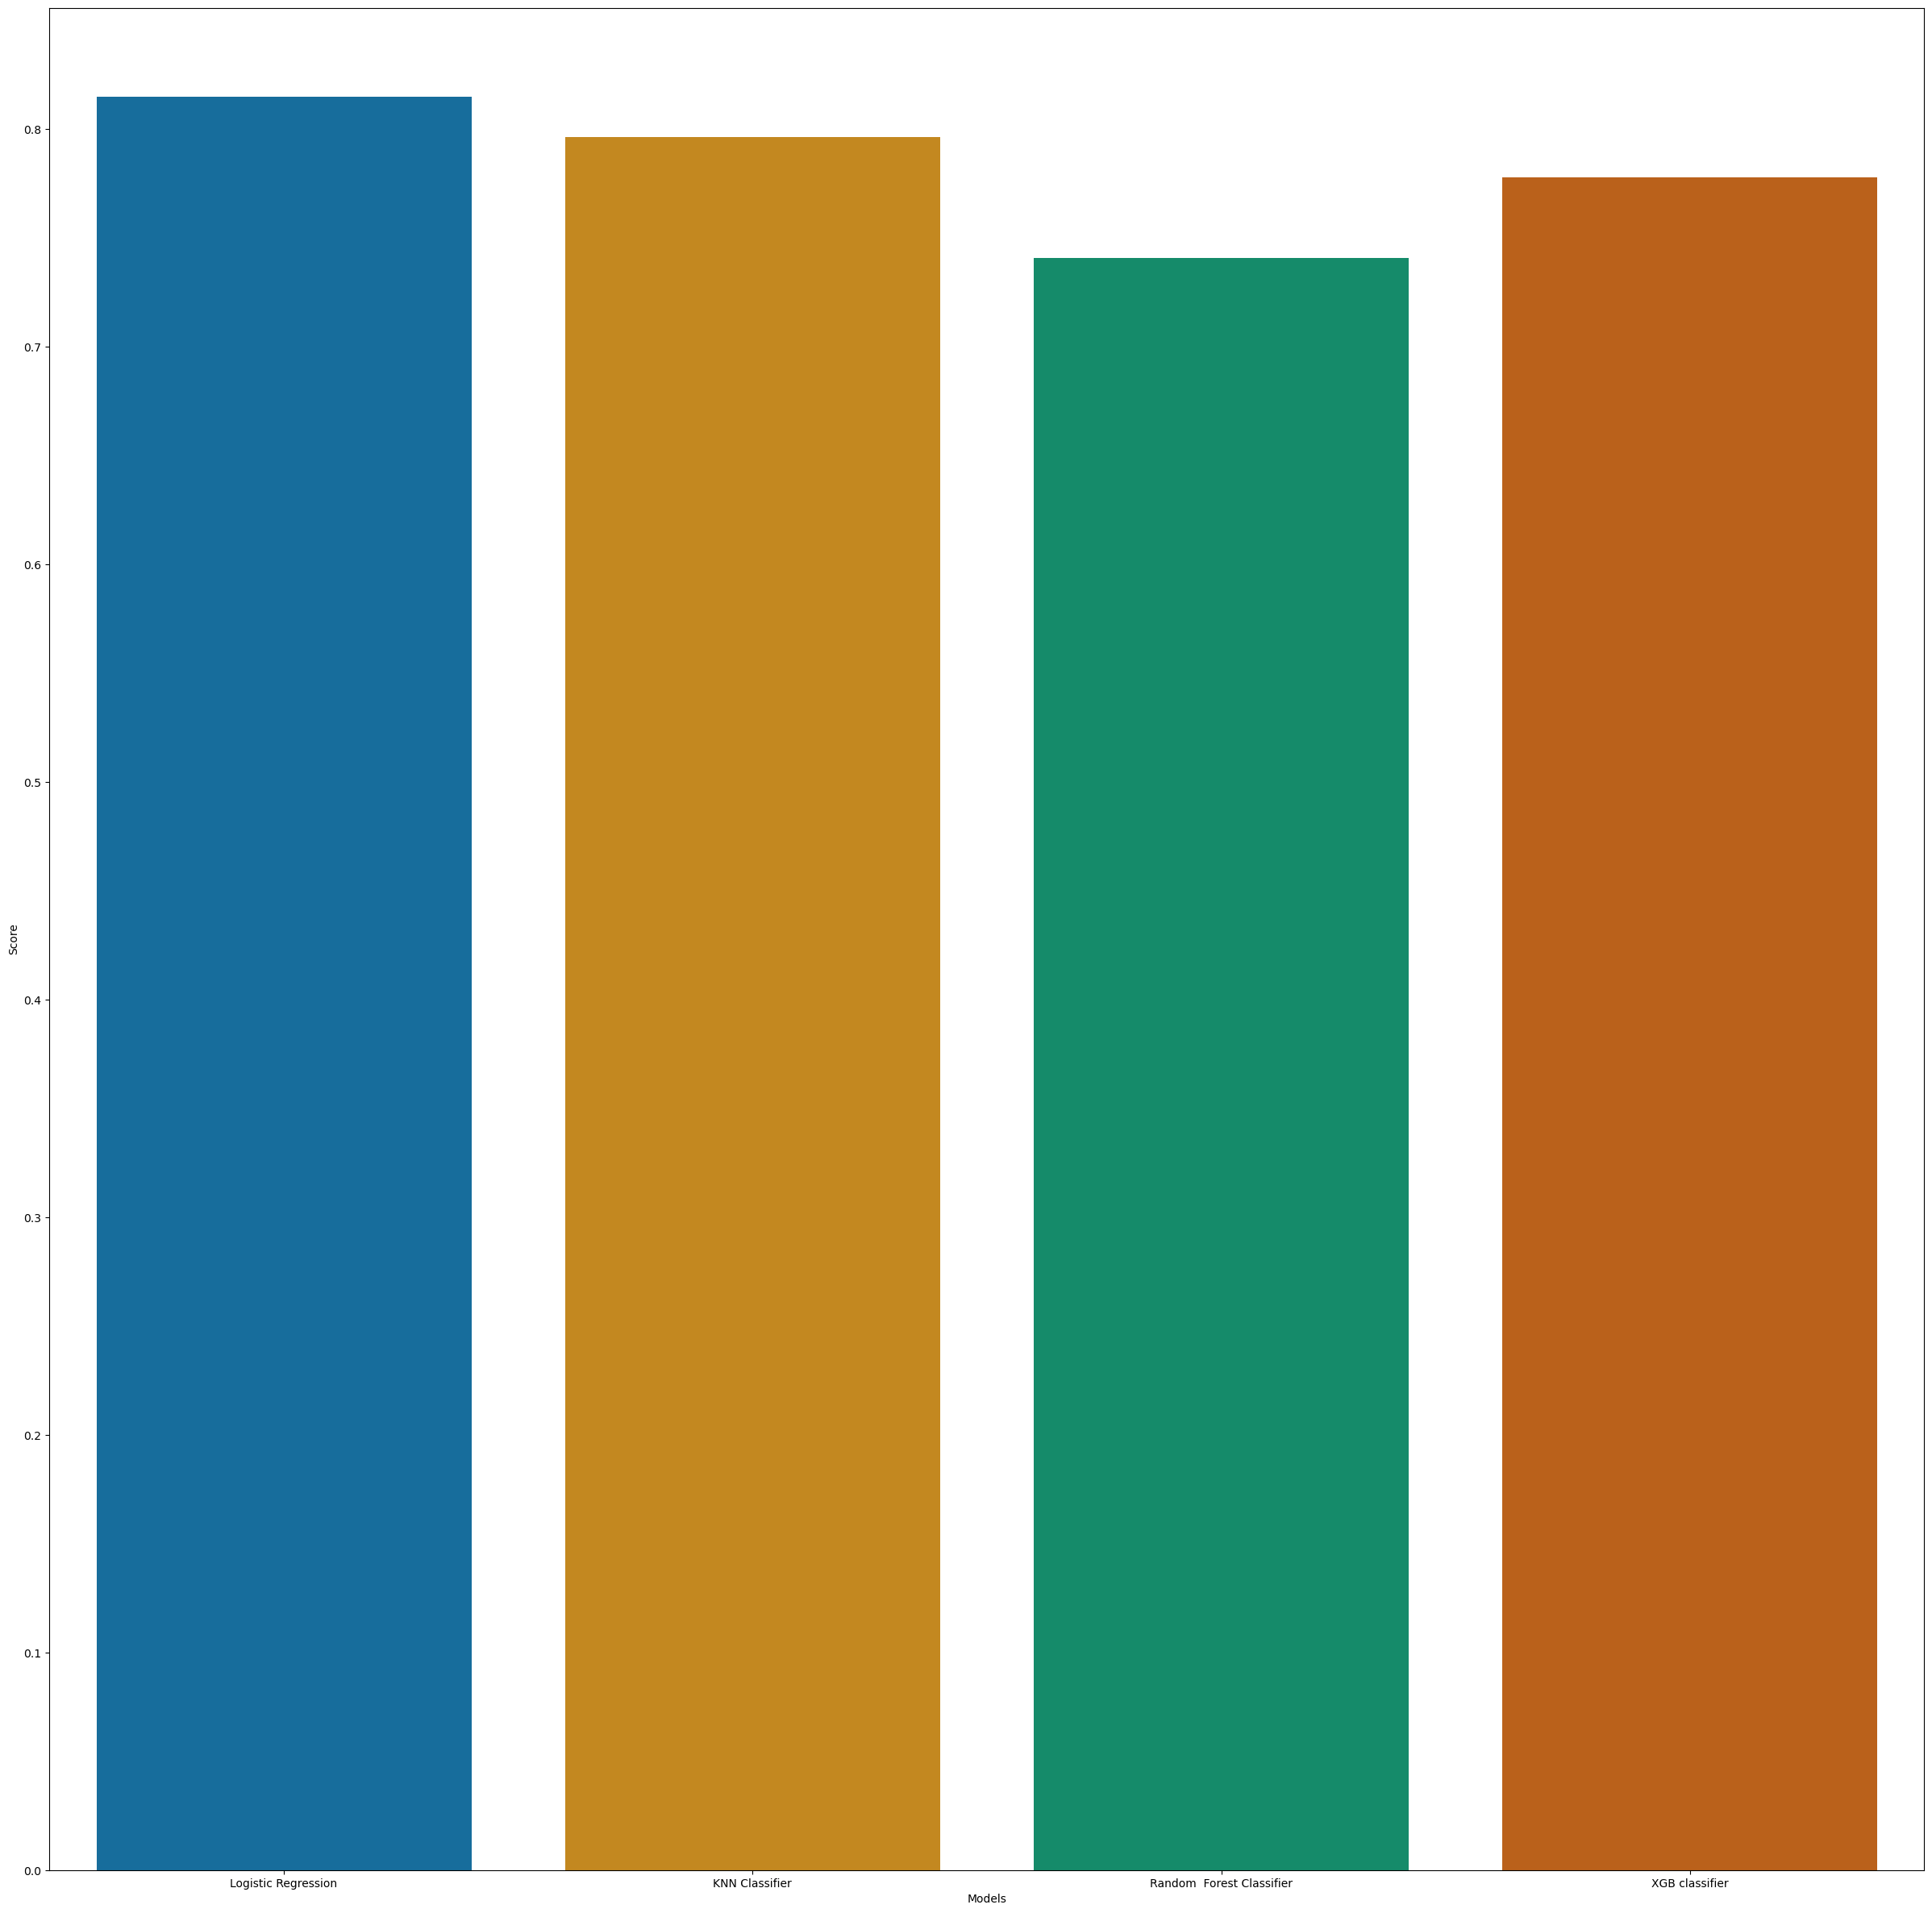

In [31]:
plt.figure(figsize = (30,30))
sns.barplot(data = data, x = "Models", y = "Score", hue = "Models", palette = "colorblind")